In [53]:

remotes::install_version("Matrix", version = "1.5-3")
packageVersion("Matrix")

[1] ‘1.5.3’

In [51]:

packageVersion("Matrix")

ERROR: Error in packageVersion("Matrix"): 不存在叫‘Matrix’这个名字的程辑包


In [ ]:
remove.packages("SeuratObject")
remotes::install_version("SeuratObject", version = "4.1.4")
packageVersion("SeuratObject")

In [1]:
library(Scissor)
library(Seurat)




载入需要的程辑包：Seurat

Attaching SeuratObject

载入需要的程辑包：Matrix



In [2]:
getwd()
data <- readRDS("all_cell.rds")

[1] "/mnt/8Tdisk/GQJ/neoadjuvant/scRNA"

In [4]:
data <- FindNeighbors(data, dims = 1:20)

Computing nearest neighbor graph

Computing SNN



In [21]:


# 假设 data 是你的 Seurat 对象
subset_data <- subset(data, subset = Resource == "Pre_biopsy")
#[1] 33694 4102

[1] 33694  4102

In [5]:
bulk_dataset=read.csv("TPM9_STAR.csv")
rownames(bulk_dataset) <- bulk_dataset[,1]
bulk_dataset <- bulk_dataset[,-1]

bulk_dataset <- as.matrix(bulk_dataset)
head(bulk_dataset)

,A568,A592,A608,A623,A624,A644,A876,A948,B132
A1BG,0.04327299,0.1243397,7.048739e-02,0.000000e+00,0.07683033,0.0000000,0.4806086,0.05051606,0.000000e+00
A1BG-AS1,0.18805924,1.1237147,1.629117e+00,4.757263e-02,0.01821248,0.8342681,1.8124799,0.13471574,2.036533e+00
A1CF,0.00000000,0.0000000,0.000000e+00,0.000000e+00,0.00000000,0.0000000,0.0000000,0.00000000,0.000000e+00
A2M,245.01080490,2693.5505190,1.435797e+03,1.056450e+03,168.51275200,354.8134376,2543.5231230,123.30895920,1.560304e+03
A2M-AS1,0.29350186,2.6143607,2.055767e+00,1.715084e+00,1.50078714,0.7360100,4.3562229,7.24659208,2.742144e-02
A2ML1,27.27765912,1.2420441,4.047384e+00,7.177643e-01,10.55347859,5.7773443,1.6969331,61.03321894,7.534825e+00


In [6]:
library(readxl )
bulk_survival<- read_excel("clinical.xlsx")
bulk_survival <- as.data.frame(bulk_survival)
rownames(bulk_survival) <- bulk_survival[,1]

head(bulk_survival)

,ID,MPR_MPR
,<chr>,<chr>
A568,A568,MPR
A592,A592,NO-MPR
A608,A608,NO-MPR
A623,A623,MPR
A624,A624,MPR
A644,A644,NO-MPR


In [12]:
all(colnames(bulk_dataset) == bulk_survival$ID)

[1] TRUE

In [12]:
print(length(numeric_phenotype))
print(ncol(bulk_dataset))


[1] 9
[1] 9


In [7]:
subset_data <- FindNeighbors(subset_data, dims = 1:30) 

Computing nearest neighbor graph

Computing SNN



In [8]:
# 假设 phenotype_vec 是包含你的分类数据的向量
phenotype_vec <- c('MPR', 'NO-MPR', 'NO-MPR', 'MPR', 'MPR', 'NO-MPR', 'MPR', 'NO-MPR', 'MPR')

# 将 'MPR' 编码为 1，'NO-MPR' 编码为 0
numeric_phenotype <- ifelse(phenotype_vec == 'MPR', 1, 0)

# 查看转换后的数值
print(numeric_phenotype)

[1] 1 0 0 1 1 0 1 0 1


In [9]:
b=c(0,1)
b

[1] 0 1

In [10]:
infos1 <- Scissor(bulk_dataset, subset_data, numeric_phenotype, alpha = 0.05,tag=c(0,1),
                 family = "binomial", Save_file = 'Scissor_survival.RData')

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 2.5 GiB”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 1.5 GiB”


[1] "|**************************************************|"
[1] "Performing quality-check for the correlations"
[1] "The five-number summary of correlations:"
        0%        25%        50%        75%       100% 
0.04286652 0.23324502 0.29088409 0.35492129 0.70501896 
[1] "|**************************************************|"
[1] "Current phenotype contains 4 0 and 5 1 samples."
[1] "Perform logistic regression on the given phenotypes:"
[1] "alpha = 0.05"
[1] "Scissor identified 562 Scissor+ cells and 7 Scissor- cells."
[1] "The percentage of selected cell is: 4.042%"
[1] "|**************************************************|"


In [16]:
names(infos1)
# [1] "para"        "Coefs"       "Scissor_pos" "Scissor_neg"
length(infos1$Scissor_pos)
# [1] 429
infos1$Scissor_pos[1:4]
length(infos1$Scissor_neg)

[1] "para"        "Coefs"       "Scissor_pos" "Scissor_neg"

[1] 549

[1] "FZC20200828_451292" "FZC20200828_836819" "FZC20200828_848946"
[4] "FZC20200828_473580"

[1] 0

In [ ]:
infos1$Scissor_pos

ERROR: Error in is.ggplot(x): 找不到对象'UMAP_celltype'


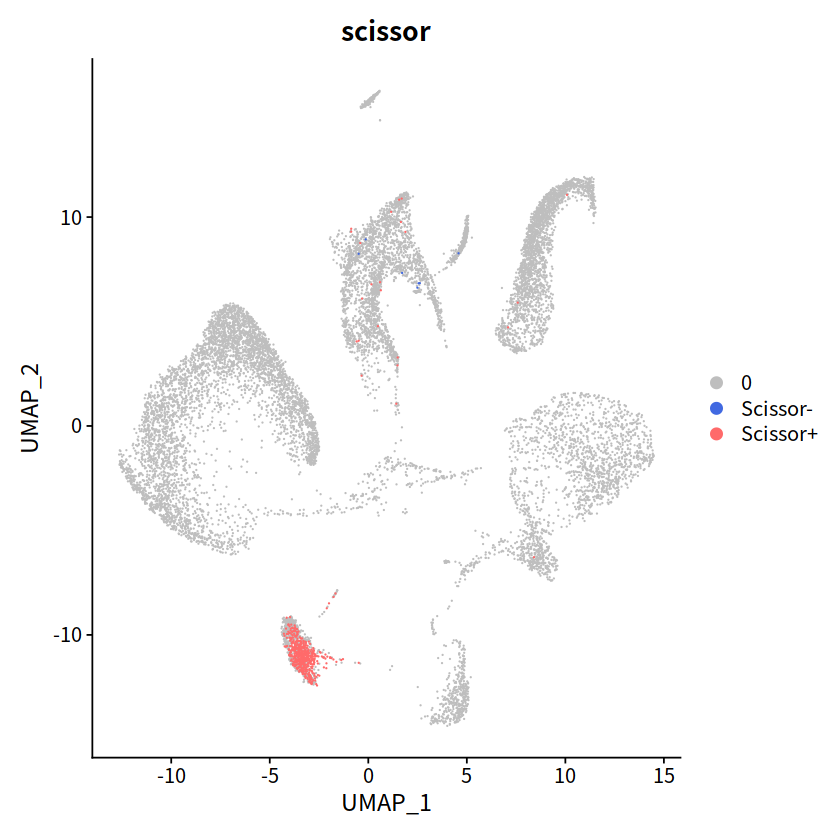

In [12]:
Scissor_select <- rep(0, ncol(subset_data))
names(Scissor_select) <- colnames(subset_data)
Scissor_select[infos1$Scissor_pos] <- "Scissor+"
Scissor_select[infos1$Scissor_neg] <- "Scissor-"
subset_data <- AddMetaData(subset_data, metadata = Scissor_select, col.name = "scissor")
UMAP_scissor <- DimPlot(subset_data, reduction = 'umap', 
        group.by = 'scissor',
        cols = c('grey','royalblue','indianred1'), 
        pt.size = 0.001, order = c("Scissor+","Scissor-"))
UMAP_scissor


In [14]:
#scissors到上面就结束了

class(subset_data)

[1] "Seurat"
attr(,"package")
[1] "SeuratObject"

In [ ]:
#导出数据：
# 加载必要的包
library(dior)
library(SingleCellExperiment)

In [16]:
# 创建一个全为"0"的向量，长度为单细胞数据的细胞数
Scissor_select <- rep("0", ncol(subset_data))
names(Scissor_select) <- colnames(subset_data)

# 标记Scissor选择的细胞
Scissor_select[infos1$Scissor_pos] <- "Scissor+"
Scissor_select[infos1$Scissor_neg] <- "Scissor-"

# 将标签添加到Seurat对象的元数据中
subset_data <- AddMetaData(subset_data, metadata = Scissor_select, col.name = "scissor")


In [ ]:
subset_data@meta.data

In [17]:
sce <- as.SingleCellExperiment(subset_data)
dior::write_h5(sce,file="subset_data.h5",object.type = "singlecellexperiment")

[1] "The first 'assayNames' defaults to 'X'"


Warning message in matrix_to_h5(mat = assay(sce, as), h5 = layers, gr_name = as):
“as is dense matrix”


In [20]:
library(ggplot2)

In [21]:
ggsave("UMAP_scissor.pdf", plot = UMAP_scissor, width = 8, height = 6)

In [18]:
table(subset_data$scissor,subset_data$all_cluster_annotation)
#           B cell  CAF HPC-like Malignant cell T cell  TAM  TEC
# 0           907  718      728           1066   2405  652  947
# Scissor-     85  225       78            101    358   52  102
# Scissor+      1    4       35            337     29   20    3

library(gplots)
balloonplot(table(subset_data$scissor,subset_data$celltype))



          
           T cell B cell Neutrophil Epithelium Myeloid cell Plasma cell
  0          4543    422       2324       2527         1810         708
  Scissor-      0      0          0          2            0           0
  Scissor+      0      0          3         19            0         540
          
           Cycling immune cell NK cell Fibroblast/Endothelium Mast cell  pDC
  0                        244     127                    552       235   17
  Scissor-                   0       0                      5         0    0
  Scissor+                   0       0                      0         0    0

Warning message:
“程辑包‘gplots’是用R版本4.2.3 来建造的”

载入程辑包：‘gplots’


The following object is masked from ‘package:stats’:

    lowess




ERROR: Error: Cannot find 'celltype' in this Seurat object


In [27]:
library(Seurat)

# 计算每个基因在多少个细胞中有表达
gene_expression_presence <- rowSums(subset_data@assays$RNA@data > 0)

# 选择一个阈值，比如基因至少在10%的细胞中有表达
cells_threshold <- ncol(subset_data@assays$RNA@data) * 0.1

# 找出满足条件的基因
genes_to_keep <- names(gene_expression_presence[gene_expression_presence > cells_threshold])

# 更新 Seurat 对象，只保留有足够表达的基因
subset_data <- subset(subset_data, features = genes_to_keep)

In [ ]:
rownames(subset_data@assays$RNA@data)

In [ ]:
colnames(subset_data@assays$RNA@data) 

In [ ]:
head(subset_data@assays$RNA@data)

In [28]:
subset_data <- FindNeighbors(subset_data, dims = 1:20) 

Computing nearest neighbor graph

Computing SNN



In [29]:
infos1 <- Scissor(bulk_dataset, subset_data, phenotype, alpha = 0.05,
                 family = "binomial", Save_file = 'Scissor_survival.RData')

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 1.5 GiB”


ERROR: Error in normalize.quantiles(as.matrix(dataset0)): ERROR; return code from pthread_create() is 22



In [20]:
Scissor <- function (bulk_dataset, sc_dataset, phenotype, tag = NULL, alpha = NULL, 
                     cutoff = 0.2, family = c("gaussian", "binomial", "cox"), 
                     Save_file = "Scissor_inputs.RData", Load_file = NULL) 
{
  library(Seurat)
  library(Matrix)
  library(preprocessCore)
  if (is.null(Load_file)) {
    common <- intersect(rownames(bulk_dataset), rownames(sc_dataset))
    if (length(common) == 0) {
      stop("There is no common genes between the given single-cell and bulk samples.")
    }
    if (class(sc_dataset) == "Seurat") {
      sc_exprs <- as.matrix(sc_dataset@assays$RNA@data)
      network <- as.matrix(sc_dataset@graphs$RNA_snn)
    }
    else {
      sc_exprs <- as.matrix(sc_dataset)
      Seurat_tmp <- CreateSeuratObject(sc_dataset)
      Seurat_tmp <- FindVariableFeatures(Seurat_tmp, selection.method = "vst", 
                                         verbose = F)
      Seurat_tmp <- ScaleData(Seurat_tmp, verbose = F)
      Seurat_tmp <- RunPCA(Seurat_tmp, features = VariableFeatures(Seurat_tmp), 
                           verbose = F)
      Seurat_tmp <- FindNeighbors(Seurat_tmp, dims = 1:10, 
                                  verbose = F)
      network <- as.matrix(Seurat_tmp@graphs$RNA_snn)
    }
    diag(network) <- 0
    network[which(network != 0)] <- 1
    dataset0 <- cbind(bulk_dataset[common, ], sc_exprs[common, 
    ])
    dataset1 <- normalize.quantiles(as.matrix(dataset0))
    rownames(dataset1) <- rownames(dataset0)
    colnames(dataset1) <- colnames(dataset0)
    Expression_bulk <- dataset1[, 1:ncol(bulk_dataset)]
    Expression_cell <- dataset1[, (ncol(bulk_dataset) + 
                                     1):ncol(dataset1)]
    X <- cor(Expression_bulk, Expression_cell)
    quality_check <- quantile(X)
    print("|**************************************************|")
    print("Performing quality-check for the correlations")
    print("The five-number summary of correlations:")
    print(quality_check)
    print("|**************************************************|")
    if (quality_check[3] < 0.01) {
      warning("The median correlation between the single-cell and bulk samples is relatively low.")
    }
    if (family == "binomial") {
      Y <- as.numeric(phenotype)
      z <- table(Y)
      if (length(z) != length(tag)) {
          print(length(tag))
          print(length(z))
        stop("The length differs between tags and phenotypes. Please check Scissor inputs and selected regression type.")
      }
      else {
        print(sprintf("Current phenotype contains %d %s and %d %s samples.", 
                      z[1], tag[1], z[2], tag[2]))
        print("Perform logistic regression on the given phenotypes:")
      }
    }
    if (family == "gaussian") {
      Y <- as.numeric(phenotype)
      z <- table(Y)
      if (length(z) != length(tag)) {
        stop("The length differs between tags and phenotypes. Please check Scissor inputs and selected regression type.")
      }
      else {
        tmp <- paste(z, tag)
        print(paste0("Current phenotype contains ", 
                     paste(tmp[1:(length(z) - 1)], collapse = ", "), 
                     ", and ", tmp[length(z)], " samples."))
        print("Perform linear regression on the given phenotypes:")
      }
    }
    if (family == "cox") {
      Y <- as.matrix(phenotype)
      if (ncol(Y) != 2) {
        stop("The size of survival data is wrong. Please check Scissor inputs and selected regression type.")
      }
      else {
        print("Perform cox regression on the given clinical outcomes:")
      }
    }
    save(X, Y, network, Expression_bulk, Expression_cell, 
         file = Save_file)
  }
  else {
    load(Load_file)
  }
  if (is.null(alpha)) {
    alpha <- c(0.005, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 
               0.6, 0.7, 0.8, 0.9)
  }
  for (i in 1:length(alpha)) {
    set.seed(123)
    fit0 <- APML1(X, Y, family = family, penalty = "Net", 
                  alpha = alpha[i], Omega = network, nlambda = 100, 
                  nfolds = min(10, nrow(X)))
    fit1 <- APML1(X, Y, family = family, penalty = "Net", 
                  alpha = alpha[i], Omega = network, lambda = fit0$lambda.min)
    if (family == "binomial") {
      Coefs <- as.numeric(fit1$Beta[2:(ncol(X) + 1)])
    }
    else {
      Coefs <- as.numeric(fit1$Beta)
    }
    Cell1 <- colnames(X)[which(Coefs > 0)]
    Cell2 <- colnames(X)[which(Coefs < 0)]
    percentage <- (length(Cell1) + length(Cell2))/ncol(X)
    print(sprintf("alpha = %s", alpha[i]))
    print(sprintf("Scissor identified %d Scissor+ cells and %d Scissor- cells.", 
                  length(Cell1), length(Cell2)))
    print(sprintf("The percentage of selected cell is: %s%%", 
                  formatC(percentage * 100, format = "f", digits = 3)))
    if (percentage < cutoff) {
      break
    }
    cat("\n")
  }
  print("|**************************************************|")
  return(list(para = list(alpha = alpha[i], lambda = fit0$lambda.min, 
                          family = family), Coefs = Coefs, Scissor_pos = Cell1, 
              Scissor_neg = Cell2))
}

In [ ]:
dim(sc_dataset)
#[1] 33694 4102

dim(bulk_dataset)
#[1] 56716   471

bulk_dataset[1:4,1:4]
#       TCGA-05-4249 TCGA-05-4250 TCGA-05-4382 TCGA-05-4384
#TSPAN6     57.52398   66.4940573   30.905120     35.10434
#TNMD       0.00000   0.1748819     0.000000     0.00000
#DPM1       98.83813 135.2046911   84.362971     89.10553
#SCYL3     16.23339   6.0050820     6.226792     16.93050

head(bulk_survival)
# TCGA_patient_barcode OS_time Status
#1         TCGA-05-4249   1158     0
#2         TCGA-05-4250     121     1
#3         TCGA-05-4382     607     0
#4         TCGA-05-4384     426     0
#5         TCGA-05-4389   1369     0
#6         TCGA-05-4390   1126     0